In [2]:
import datasets
ds = datasets.Dataset.from_json('downloaded_eval_results.json')
ds

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores'],
    num_rows: 50
})

In [9]:
import os
def map_fn(example):
    example['is_correct'] = [x==1.0 for x in example['scores']]
    return example

ds = ds.map(map_fn, num_proc=os.cpu_count())
ds

Map (num_proc=14):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores', 'is_correct'],
    num_rows: 50
})

In [12]:
import numpy as np
from scipy.special import comb
from tqdm import tqdm

def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [13]:
def calculate_pass_at_k_corrected(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    pass_at_k_values = []
    
    for k in range(1, n_samples + 1):
        pass_at_k_per_problem = []
        
        for problem_idx in range(n_problems):
            correct_samples = np.sum(correctness_matrix[problem_idx])
            
            pass_k = pass_at_k(n_samples, correct_samples, k)
            pass_at_k_per_problem.append(pass_k)
        
        avg_pass_at_k = np.mean(pass_at_k_per_problem)
        pass_at_k_values.append(avg_pass_at_k)
    
    return np.array(pass_at_k_values)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

correctness_matrix = np.array(ds["is_correct"])
pass_at_k_values = np.asarray(calculate_pass_at_k_corrected(correctness_matrix))

print(pass_at_k_values)

[0.315      0.47533333 0.56214286 0.61304396 0.64549451 0.66786464
 0.68441084 0.69743745 0.70824825 0.7175999  0.72594322 0.73356044
 0.74064286 0.74733333 0.75375    0.76      ]


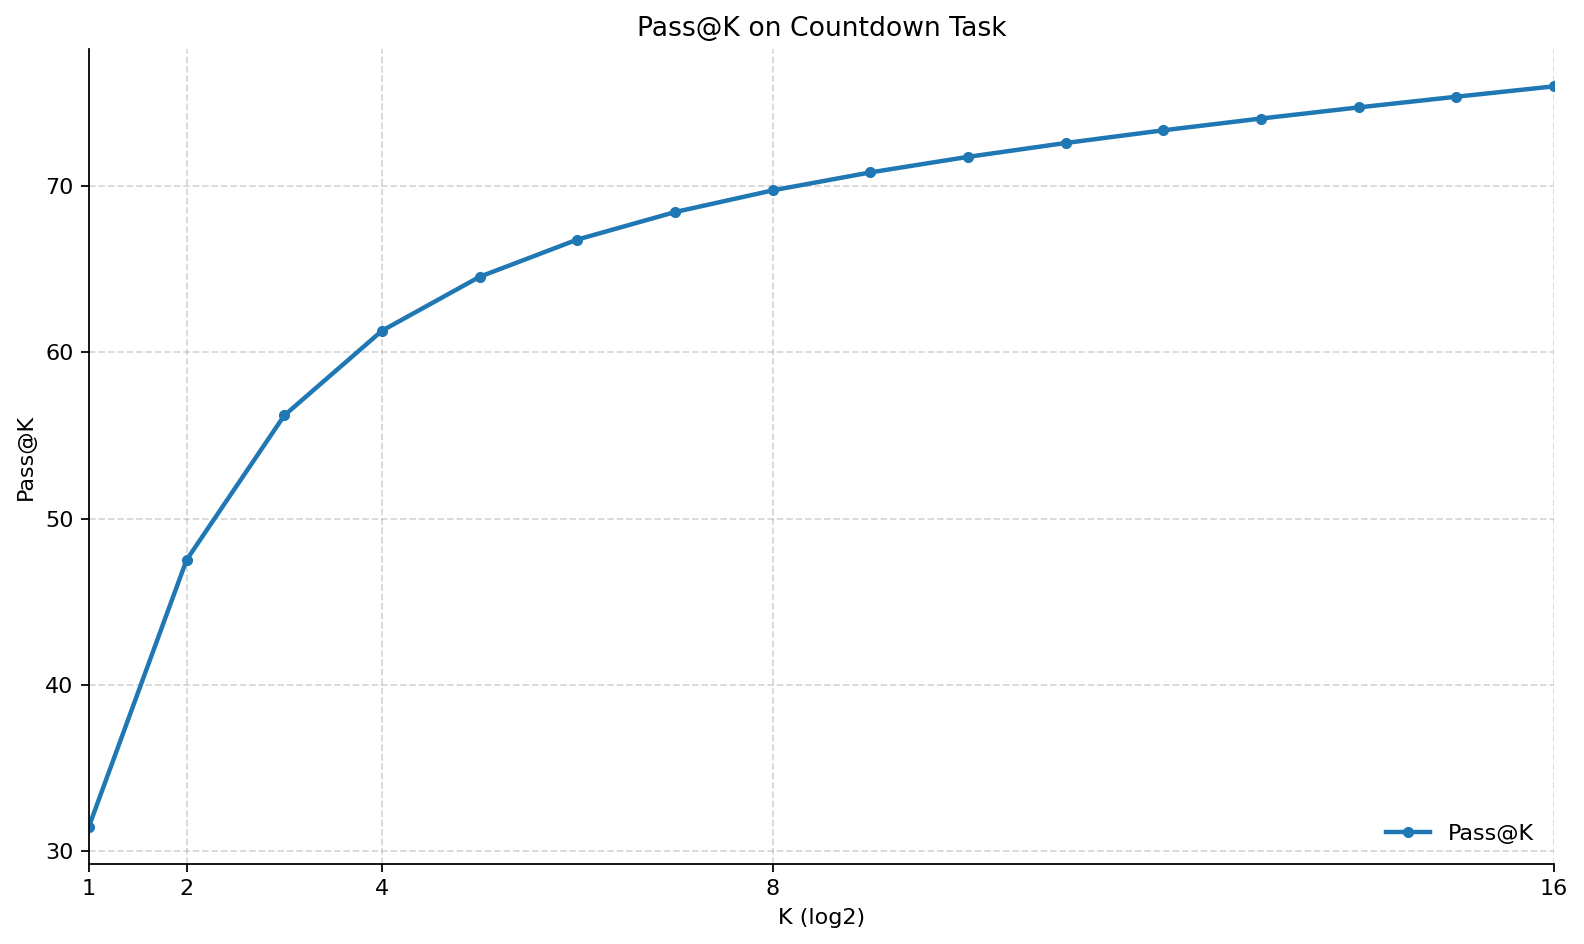

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

k = np.arange(1, len(pass_at_k_values) + 1)

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=160)

ax.plot(k, pass_at_k_values * 100, marker="o", markersize=4, linewidth=2, label="Pass@K")

ax.set_xlabel("K (log2)")
ax.set_ylabel("Pass@K")
ax.set_title("Pass@K on Countdown Task")
ax.set_xlim(1, k[-1])

major_ticks = [t for t in [1, 2, 4, 8, 16] if t <= k[-1]]
ax.xaxis.set_major_locator(FixedLocator(major_ticks))
ax.set_xticklabels([str(t) for t in major_ticks])

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
fig.savefig("eval_results/sft_pass_at_k.png", bbox_inches="tight", dpi=300)
plt.show()